# `SurfTrack` - Measures
Compute shape, motion, temporal, and intensity characteristics of tracked
surface heatwave events. This notebook continues from the SurfTrack tracking tutorial and assumes 
`result` (the tracked labels DataArray) and `var_notrend` (the anomaly field)
are already in memory.

### 1. Imports

In [3]:
# Measures sub-modules
from ocetrac.SurfTrack.measures.utils import (
    ShapeMeasures,
    MotionMeasures,
    get_duration,
    get_initial_detection_time,
    calculate_intensity_metrics,
    get_object_masks,
    run_shape_measures,
    run_motion_measures,
    run_temporal_measures,
    run_intensity_measures,
    process_objects_and_calculate_measures,
    lons_to_180,
)
from ocetrac.SurfTrack.measures.plotting import plot_displacement

### 2. Recap

After running `SurfTracker.run()` we have:
- `result` — DataArray (time, lat, lon) of integer event labels, NaN = background
- `var_notrend` — DataArray (time, lat, lon) of SST anomalies (from `calculate_anomalies_trend_features`)

In [44]:
# All unique event IDs
event_ids = np.unique(result.values)
event_ids = event_ids[~np.isnan(event_ids)]
print(f"Total tracked events: {len(event_ids)}")
print(f"Event IDs: {event_ids[:]} ...")

Total tracked events: 60
Event IDs: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60.] ...


In [26]:
anom

<xarray.DataArray (time: 433, lat: 138, lon: 288)> Size: 138MB
array([[[-0.38585486, -0.3697699 , -0.35270895, ..., -0.43246681,
         -0.42097259, -0.40316005],
        [-0.47201802, -0.46155738, -0.45422549, ..., -0.48133999,
         -0.48522698, -0.48176319],
        [-0.54543594, -0.54607625, -0.53813248, ..., -0.47048807,
         -0.50495293, -0.53207767],
        ...,
        [ 0.46768138,  0.43471435,  0.40061251, ...,  0.43944371,
          0.50179589,  0.51046424],
        [ 0.6230039 ,  0.55412768,  0.49083757, ...,  0.5840006 ,
          0.65754218,  0.67407608],
        [ 0.79466408,  0.69131989,  0.58016453, ...,  0.78568523,
          0.84079187,  0.8529317 ]],

       [[-0.48895671, -0.46554217, -0.44811693, ..., -0.64097775,
         -0.59068515, -0.53084162],
        [-0.51441074, -0.47031967, -0.44859089, ..., -0.6258642 ,
         -0.60710446, -0.57394917],
        [-0.50192003, -0.46226531, -0.43666332, ..., -0.5055735 ,
         -0.52035278, -0.53196638],
...
        [ 0.63446571,  0.68550002,  0.72682059, ...,  0.41717646,
          0.4511896 ,  0.55592058],
        [ 0.71495333,  0.76664366,  0.81480749, ...,  0.45474103,
          0.52750041,  0.63158104],
        [ 0.7618968 ,  0.82198597,  0.88405636, ...,  0.50531523,
          0.59544083,  0.68877213]],

       [[ 0.12935723,  0.08974562,  0.03704887, ...,  0.20346442,
          0.18456779,  0.16207527],
        [-0.00162986, -0.02147578, -0.05354738, ...,  0.03754621,
          0.02821324,  0.01754266],
        [-0.15763966, -0.17312524, -0.19530826, ..., -0.12498589,
         -0.13530935, -0.14498376],
        ...,
        [ 0.29400464,  0.2701163 ,  0.27314633, ...,  0.30132432,
          0.32881736,  0.32516775],
        [ 0.23614736,  0.24571236,  0.27539847, ...,  0.3047578 ,
          0.31212475,  0.26960691],
        [ 0.25130636,  0.29760109,  0.36536933, ...,  0.25533547,
          0.25633358,  0.24157431]]], shape=(433, 138, 288))
Coordinates:
  * time     (time) object 3kB 1979-01-01 00:00:00 ... 2015-01-01 00:00:00
  * lat      (lat) float64 1kB -64.55 -63.61 -62.67 -61.73 ... 62.67 63.61 64.55
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    units:         K
    long_name:     sea surface temperature
    cell_methods:  time: mean

### 3. Select a region

In [30]:
# Defining our region (Pacific Ocean)
upper_lat = 65
lower_lat = 5
left_lon  = 150
right_lon = 250

result_NP   = result.sel(lat=slice(lower_lat, upper_lat),
                          lon=slice(left_lon,  right_lon))
var_notrend_NP = anom.sel(lat=slice(lower_lat, upper_lat),
                                  lon=slice(left_lon,  right_lon))

# Event IDs present in this region
ids_NP = np.unique(result_NP.values)
ids_NP = ids_NP[~np.isnan(ids_NP)]
print(f"Events in North Pacific: {ids_NP}")

Events in North Pacific: [ 6.  9. 28. 34. 38. 39. 42. 43. 48. 59.]


### 4. Extract one event

`get_object_masks` extracts the binary mask and intensity field for a
single event ID.

Returns:
- `event_binary`   — DataArray, 1 where event is present, NaN elsewhere
- `event_intensity` — DataArray, anomaly values inside the event, NaN elsewhere

In [46]:
object_id = ids_NP[5]   # pick the first event in the region
print(f"Analysing event ID: {object_id}")

event_binary, event_intensity = get_object_masks(result_NP, var_notrend_NP,
                                                  object_id=object_id)

print(f"Active timesteps: {event_binary.time.shape[0]}")
print(f"event_binary dims  : {event_binary.dims}")
print(f"event_intensity dims: {event_intensity.dims}")

Analysing event ID: 39.0
Active timesteps: 7
event_binary dims  : ('time', 'lat', 'lon')
event_intensity dims: ('time', 'lat', 'lon')


/glade/derecho/scratch/cassiacai/tmp/ipykernel_2931/3397323041.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


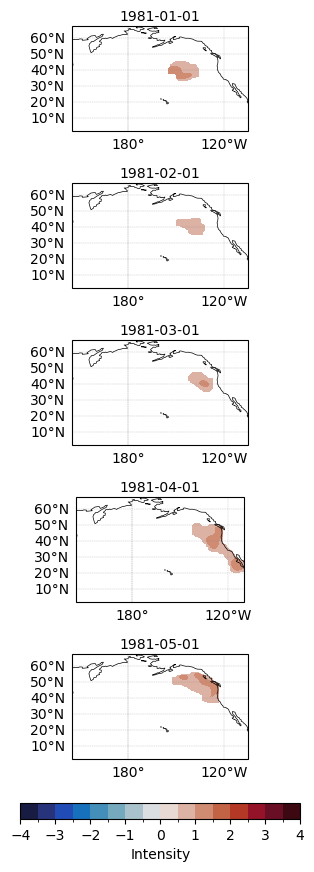

In [39]:
# Quick plot — event extent over first 5 active timesteps

fig, axes = plt.subplots(5, 1, figsize=(4, 8), 
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

for i, ax in enumerate(axes[:11]):
    contour = event_intensity.sel(lat=slice(-65, 65))[i,:,:].plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmocean.cm.balance,
        levels=17,
        vmin=-4,
        vmax=4,
        add_colorbar=False,
        extend='neither'
    )
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    time_str = str(event_intensity.time[i].values)[:10]
    ax.set_title(time_str, fontsize=10, pad=4)

cbar_ax = fig.add_axes([0.15, -0.03, 0.7, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(contour, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Intensity', fontsize=10)

plt.tight_layout()
plt.show()

### 5. Shape measures

In [40]:
lon_resolution_value = 111.320   # km per degree longitude
lat_resolution_value = 110.574   # km per degree latitude

shape_results = run_shape_measures(event_binary, lon_resolution_value, lat_resolution_value)

print(f"Max spatial extent   : {shape_results['max_spatial_extent']:.0f} km²")
print(f"Mean spatial extent  : {shape_results['mean_spatial_extent']:.0f} km²")
print()
print(f"Perimeters (km)      : {[f'{p:.0f}' for p in shape_results['perimeters']]}")
print(f"Circularity          : {[f'{c:.3f}' if c is not None else 'nan' for c in shape_results['circularity']]}")
print(f"Deformation          : {[f'{d:.3f}' for d in shape_results['deformation']]}")

Max spatial extent   : 3299569 km²
Mean spatial extent  : 1884334 km²

Perimeters (km)      : ['5923', '5105', '4884', '11333', '7764', '6712', '8042']
Circularity          : ['0.555', '0.551', '0.584', '0.323', '0.506', '0.488', '0.371']
Deformation          : ['0.706', '0.764', '0.787', '0.732', '0.669', '0.608']


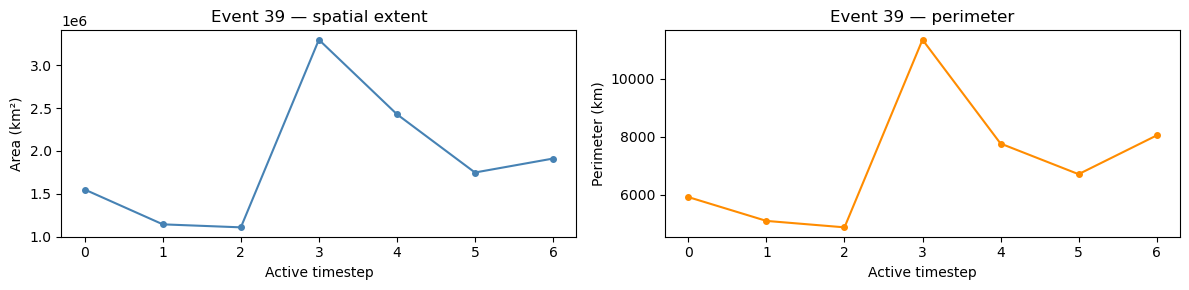

In [41]:
# Plot spatial extent over time
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(shape_results['spatial_extents'], marker='o', ms=4, color='steelblue')
axes[0].set_xlabel('Active timestep'); axes[0].set_ylabel('Area (km²)')
axes[0].set_title(f'Event {int(object_id)} — spatial extent')

axes[1].plot(shape_results['perimeters'], marker='o', ms=4, color='darkorange')
axes[1].set_xlabel('Active timestep'); axes[1].set_ylabel('Perimeter (km)')
axes[1].set_title(f'Event {int(object_id)} — perimeter')

plt.tight_layout(); plt.show(); plt.close()

## 6. Motion measures

Motion measures require longitudes in (−180, 180) format.
`lons_to_180` converts from (0, 360).

In [42]:
# Convert longitudes for motion measures
event_binary_180   = lons_to_180(event_binary.copy())
event_intensity_180 = lons_to_180(event_intensity.copy())

motion_results = run_motion_measures(event_binary_180, event_intensity_180)

print(f"Centroids per timestep : {motion_results['num_centroids_per_timestep']}")
print(f"Centroid displacements : "
      f"{[f'{d:.1f}' for d in motion_results['centroid_displacements_km']]} km")
print()
print("Centroid directionality:")
for k, v in motion_results['centroid_directionality'].items():
    print(f"  {k:<20} {v}")
print()
print("COM directionality:")
for k, v in motion_results['com_directionality'].items():
    print(f"  {k:<20} {v}")

Centroids per timestep : [1, 1, 1, 1, 1, 1, 1]
Centroid displacements : ['435.3', '531.1', '763.2', '1265.6', '531.5', '135.5'] km

Centroid directionality:
  mean_delta_lon       1.884816753926702
  mean_delta_lat       1.25
  mean_angle           33.55211647750917
  direction            eastward (zonal-dominated)
  movement_count       6

COM directionality:
  mean_delta_lon       1.884816753926702
  mean_delta_lat       1.6666666666666667
  mean_angle           41.48501950343204
  direction            eastward (zonal-dominated)
  movement_count       6


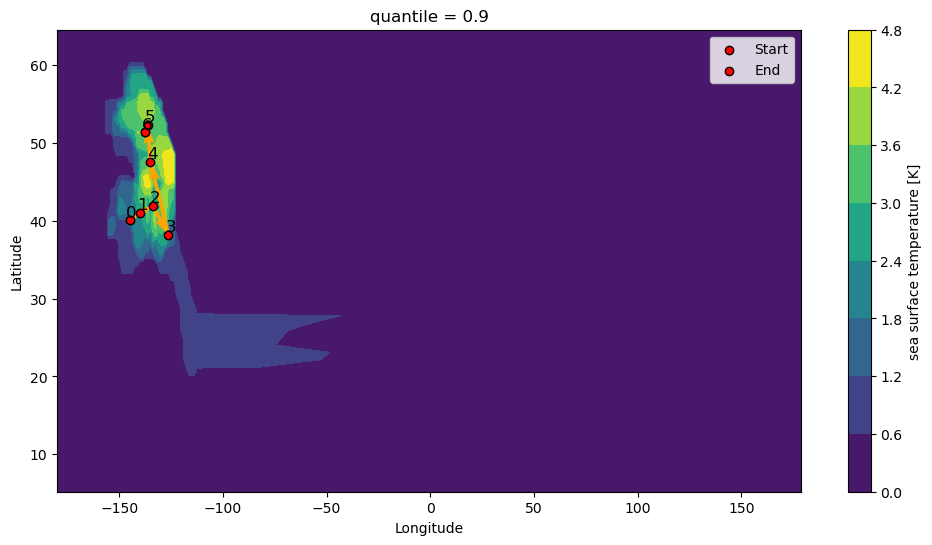

In [43]:
# Plot centroid displacement path
plot_displacement(motion_results['centroid_path'], event_intensity_180)

### 7. Temporal measures

In [47]:
temporal_results = run_temporal_measures(event_binary)

print(f"Initial detection : {temporal_results['initial_detection_date']}")
print(f"Duration          : {temporal_results['duration']} timesteps")

Initial detection : 1981-01-01 00:00:00
Duration          : 7 timesteps


### 8. Intensity measures

In [48]:
intensity_results = run_intensity_measures(event_intensity)

print(f"Max intensity            : {intensity_results['max_intensity']:.4f} °C")
print(f"90th percentile (global) : "
      f"{float(intensity_results['percentile_90_intensity_timeseries'].max()):.4f} °C")

# Full intensity metrics
full_metrics = calculate_intensity_metrics(event_intensity, quantile_threshold=0.9)
print()
print(f"Mean intensity           : {full_metrics['mean_intensity']:.4f} °C")
print(f"Std intensity            : {full_metrics['std_intensity']:.4f} °C")

Max intensity            : 1.5718 °C
90th percentile (global) : 1.3864 °C

Mean intensity           : 0.9667 °C
Std intensity            : 0.1835 °C


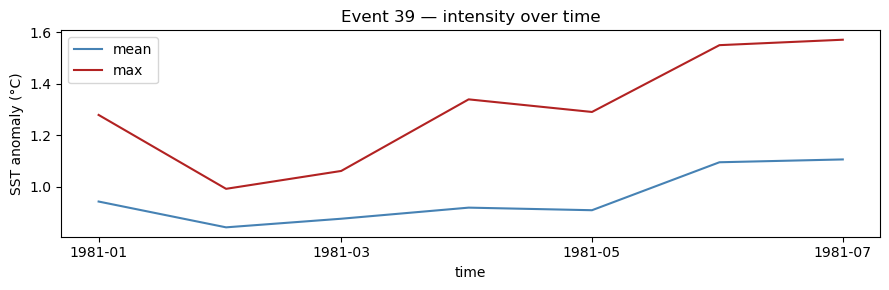

In [49]:
fig, ax = plt.subplots(figsize=(9, 3))
full_metrics['mean_intensity_timeseries'].plot(ax=ax, label='mean', color='steelblue')
full_metrics['max_intensity_timeseries'].plot(ax=ax, label='max',  color='firebrick')
ax.set_title(f'Event {int(object_id)} — intensity over time')
ax.set_ylabel('SST anomaly (°C)')
ax.legend(); plt.tight_layout(); plt.show(); plt.close()

### 9. One event, all measures at once

Use the convenience wrappers to run all measure groups in a single call.

In [50]:
measure_results = {}

event_binary, event_intensity = get_object_masks(result_NP, var_notrend_NP,
                                                  object_id=object_id)
event_binary_180    = lons_to_180(event_binary.copy())
event_intensity_180 = lons_to_180(event_intensity.copy())

measure_results['shape_measures']    = run_shape_measures(
    event_binary, lon_resolution_value, lat_resolution_value)

measure_results['motion_measures']   = run_motion_measures(
    event_binary_180, event_intensity_180)

measure_results['temporal_measures'] = run_temporal_measures(event_binary)

measure_results['intensity_measures'] = run_intensity_measures(event_intensity)

print("All measures computed for event", int(object_id))
print("Keys:", list(measure_results.keys()))

All measures computed for event 39
Keys: ['shape_measures', 'motion_measures', 'temporal_measures', 'intensity_measures']


### 10. Multiple events, multiple measures

`process_objects_and_calculate_measures` loops over a list of event IDs and
returns a nested dict keyed by event ID.  Individual measure groups can be
switched on/off with boolean flags.

In [51]:
my_object_ids = list(ids_NP[:3])   # first 3 events in the North Pacific
print("Processing event IDs:", my_object_ids)

results_multi = process_objects_and_calculate_measures(
    my_object_ids,
    blobs          = result_NP,
    var_notrend    = var_notrend_NP,
    run_shape      = True,
    run_motion     = False,   # turn off motion for speed
    run_temporal   = True,
    run_intensity  = True,
    lon_resolution_value = lon_resolution_value,
    lat_resolution_value = lat_resolution_value,
)

Processing event IDs: [np.float64(6.0), np.float64(9.0), np.float64(28.0)]
Shape Measures complete.
Temporal Measures complete.
Intensity Measures complete.
Shape Measures complete.
Temporal Measures complete.
Intensity Measures complete.
Shape Measures complete.
Temporal Measures complete.
Intensity Measures complete.


In [52]:
# Summary table
print(f"{'Event ID':<12} {'Duration':>10} {'Max area (km²)':>16} {'Max intensity':>15}")
print("-" * 56)
for eid, res in results_multi.items():
    dur     = res['temporal_measures']['duration']
    maxarea = res['shape_measures']['max_spatial_extent']
    maxint  = res['intensity_measures']['max_intensity']
    print(f"{int(eid):<12} {dur:>10} {maxarea:>16.0f} {maxint:>15.4f}")

Event ID       Duration   Max area (km²)   Max intensity
--------------------------------------------------------
6                    22          9613349          4.1525
9                     4          2002339          2.9356
28                    3           110139          0.7067


## Example of a previous event has a centroid that moves more

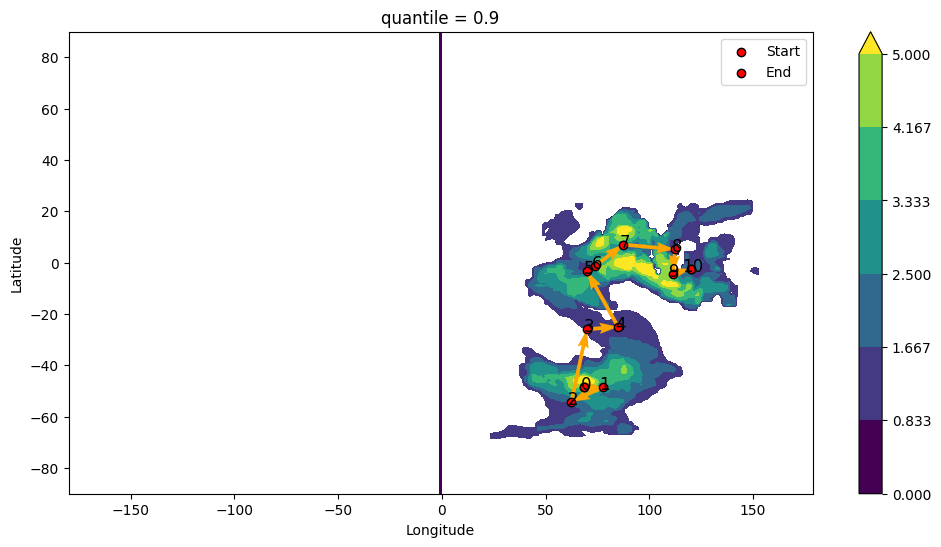

In [70]:
plot_displacement(centroid_path, event_intensity)